# Batch recipe generation — metrics across batches

Notebook companion to `00_batch_recipe_generation.py`.

Simulates the Sequential Batch Control recipe for `N_BATCHES` batches and shows **one plot per metric across all batches**:
- Per-batch scalar metrics (yield, final/max penicillin conc, final volume, mean pH, mean temperature) as bar charts.
- Per-batch time-series metrics (penicillin conc, PAA conc, viscosity, PAA flow-rate setpoint) overlaid across batches.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- make the notebook runnable from the experiments/ dir (no -m / PYTHONPATH) ---
_ROOT = os.path.dirname(os.path.abspath("00_batch_recipe_generation.ipynb"))  # .../experiments
_ROOT = os.path.dirname(_ROOT)                 # .../pensim_mcpilco
sys.path.insert(0, _ROOT)                      # for `utils`, `mcpilco`
sys.path.insert(0, os.path.dirname(_ROOT))     # repo root, for `PenSimPy`

from utils.recipe import Recipe, RecipeCombo
from utils.peni_env_setup import PenSimEnv
from PenSimPy.pensimpy.data.constants import FS, FOIL, FG, PRES, DISCHARGE, WATER, PAA
from PenSimPy.pensimpy.data.constants import FS_DEFAULT_PROFILE, FOIL_DEFAULT_PROFILE, FG_DEFAULT_PROFILE, \
    PRESS_DEFAULT_PROFILE, DISCHARGE_DEFAULT_PROFILE, WATER_DEFAULT_PROFILE, PAA_DEFAULT_PROFILE

from utils.ode_patch import patch_fastodeint
# must run before any PenSimEnv.step()
patch_fastodeint()

CONC_COL = "Penicillin Concentration"
N_BATCHES = 10

## Run the batches

In [2]:
recipe_dict = {FS: Recipe(FS_DEFAULT_PROFILE, FS),
               FOIL: Recipe(FOIL_DEFAULT_PROFILE, FOIL),
               FG: Recipe(FG_DEFAULT_PROFILE, FG),
               PRES: Recipe(PRESS_DEFAULT_PROFILE, PRES),
               DISCHARGE: Recipe(DISCHARGE_DEFAULT_PROFILE, DISCHARGE),
               WATER: Recipe(WATER_DEFAULT_PROFILE, WATER),
               PAA: Recipe(PAA_DEFAULT_PROFILE, PAA)}

recipe_combo = RecipeCombo(recipe_dict=recipe_dict)
env = PenSimEnv(recipe_combo=recipe_combo, fast=True)

per_batch = []
conc_curves = {}   # Penicillin concentration (g/L)
paa_curves = {}    # PAA concentration (mg/L)
visc_curves = {}   # Viscosity (cP)
fpaa_curves = {}   # PAA flow-rate setpoint (L/h)
age_curves = {}    # Age of culture (h)

for i in range(N_BATCHES):
    (df, _df_raman), batch_yield, bx = env.get_batches(
        random_seed=i, include_raman=False, return_batch_data=True)
    conc_curves[f"batch_{i}"] = df[CONC_COL]
    paa_curves[f"batch_{i}"] = pd.Series(bx.PAA.y, index=df.index)
    visc_curves[f"batch_{i}"] = pd.Series(bx.Viscosity.y, index=df.index)
    fpaa_curves[f"batch_{i}"] = df["Phenylacetic acid flow-rate"]
    age_curves[f"batch_{i}"] = pd.Series(bx.Culture_age.y, index=df.index)
    per_batch.append({
        "batch": i,
        "yield": batch_yield,
        "final_penicillin_conc": df[CONC_COL].iloc[-1],
        "max_penicillin_conc": df[CONC_COL].max(),
        "final_volume": df["Volume"].iloc[-1],
        "mean_pH": df["pH"].mean(),
        "mean_temperature": df["Temperature"].mean(),
    })
    print(f"batch {i}: yield={batch_yield:.2f}, final conc={df[CONC_COL].iloc[-1]:.3f}")

metrics = pd.DataFrame(per_batch).set_index("batch")
summary = metrics.agg(["mean", "std"])

conc_df = pd.DataFrame(conc_curves); conc_df.index.name = "time_h"
paa_df = pd.DataFrame(paa_curves);   paa_df.index.name = "time_h"
visc_df = pd.DataFrame(visc_curves); visc_df.index.name = "time_h"
fpaa_df = pd.DataFrame(fpaa_curves); fpaa_df.index.name = "time_h"
age_df = pd.DataFrame(age_curves); age_df.index.name = "time_h"

metrics

batch 0: yield=2986.22, final conc=21.651
batch 1: yield=3638.54, final conc=29.032
batch 2: yield=3207.17, final conc=23.582
batch 3: yield=3259.61, final conc=25.615
batch 4: yield=3951.48, final conc=31.377
batch 5: yield=3601.83, final conc=28.774
batch 6: yield=3596.43, final conc=27.203
batch 7: yield=3339.98, final conc=25.013
batch 8: yield=3579.96, final conc=28.381
batch 9: yield=3691.23, final conc=29.270


,yield,final_penicillin_conc,max_penicillin_conc,final_volume,mean_pH,mean_temperature
batch,,,,,,
0,2986.218667,21.651001,21.651001,99644.428549,6.430185,297.995351
1,3638.542090,29.032295,29.032295,87886.112903,6.498054,298.031107
2,3207.172662,23.582071,23.582071,97347.318512,6.492212,297.981455
3,3259.614084,25.615054,25.654043,89821.217526,6.498247,297.996329
4,3951.475387,31.376919,31.376919,88273.778464,6.497126,298.098451
5,3601.826019,28.773689,28.773689,88590.219584,6.498225,298.003109
6,3596.428377,27.202644,27.330179,92598.909111,6.497739,297.997269
7,3339.984511,25.012950,25.012950,96403.209682,6.476738,297.973422
8,3579.961310,28.381496,28.435936,88553.740563,6.498478,298.013254


In [3]:
summary

,yield,final_penicillin_conc,max_penicillin_conc,final_volume,mean_pH,mean_temperature
mean,3485.245701,26.989793,27.011890,91758.243707,6.488565,298.010853
std,282.171674,2.975730,2.977866,4444.217219,0.021592,0.035140


## Per-batch scalar metrics — one plot per metric

Each bar chart shows one metric across all batches, with the mean drawn as a dashed line.

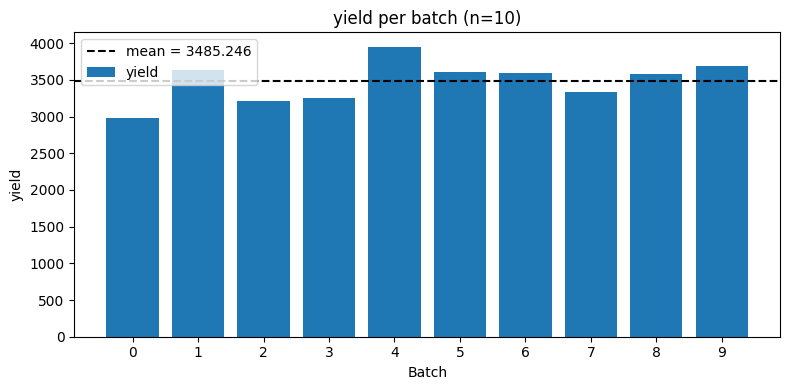

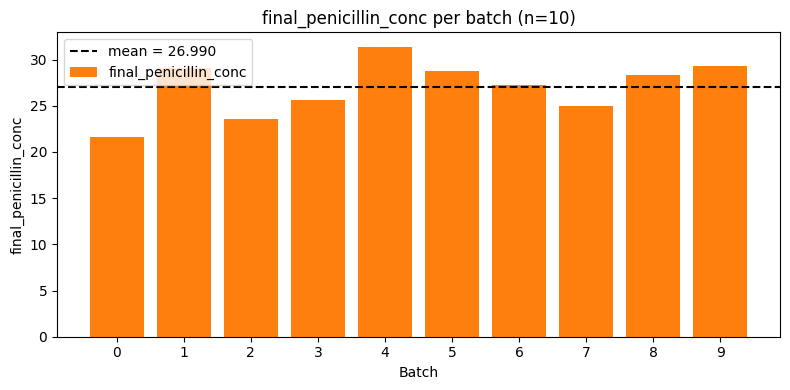

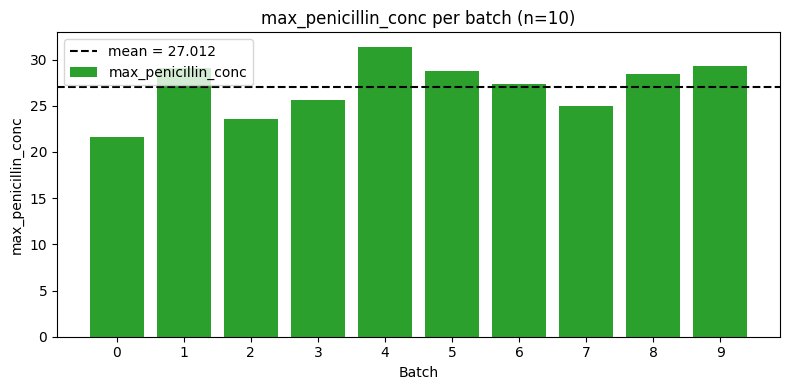

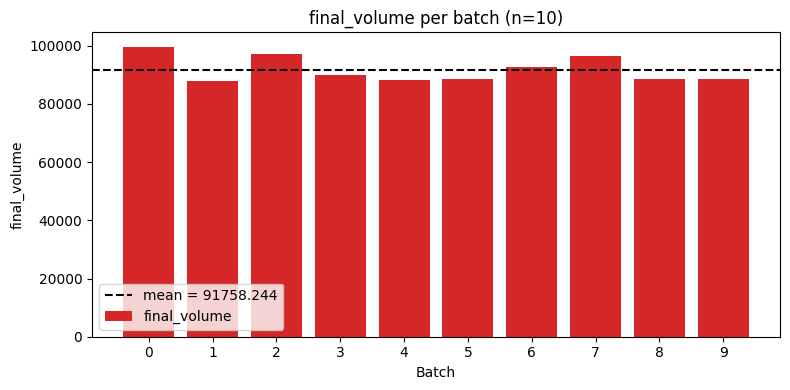

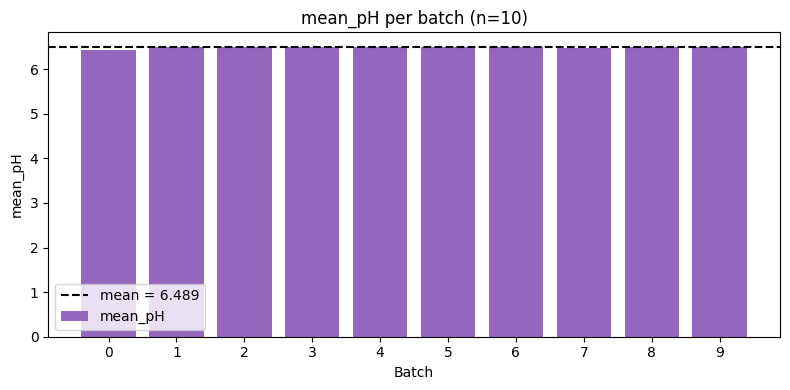

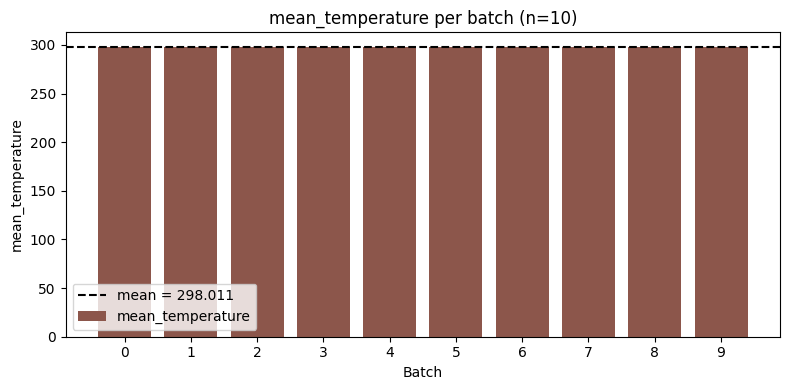

In [4]:
scalar_metrics = list(metrics.columns)

for j, col in enumerate(scalar_metrics):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(metrics.index, metrics[col], color=f"C{j % 10}", label=col)
    m = metrics[col].mean()
    ax.axhline(m, color="k", linestyle="--", label=f"mean = {m:.3f}")
    ax.set_xlabel("Batch")
    ax.set_ylabel(col)
    ax.set_title(f"{col} per batch (n={N_BATCHES})")
    ax.set_xticks(metrics.index)
    ax.legend()
    fig.tight_layout()
    plt.show()

## Per-batch time-series metrics — one plot per metric

Each metric is overlaid across all batches (thin grey lines), with the across-batch mean ± 1 std highlighted.

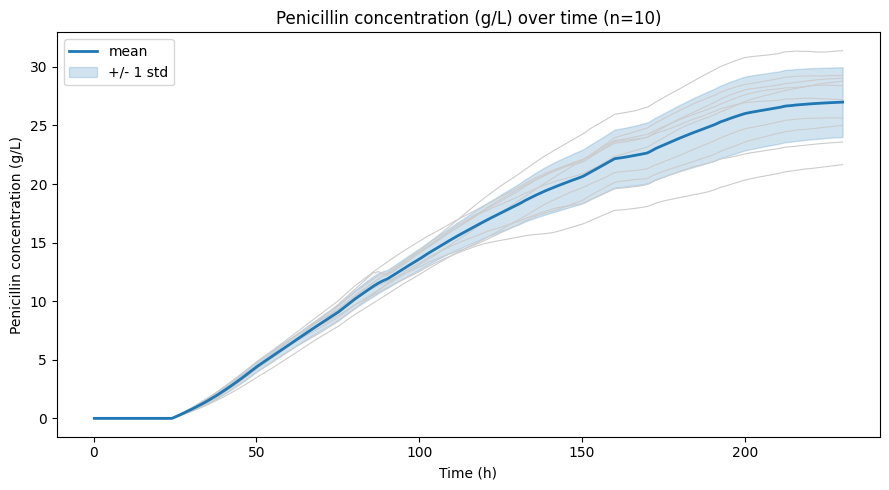

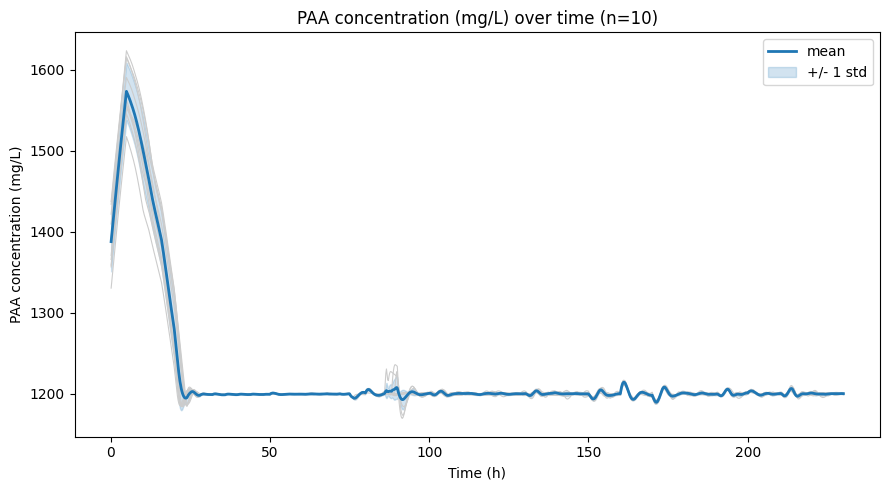

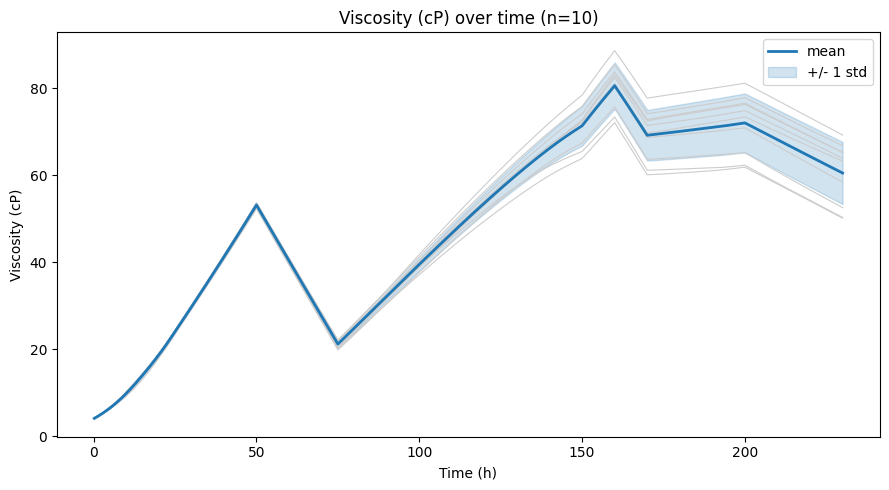

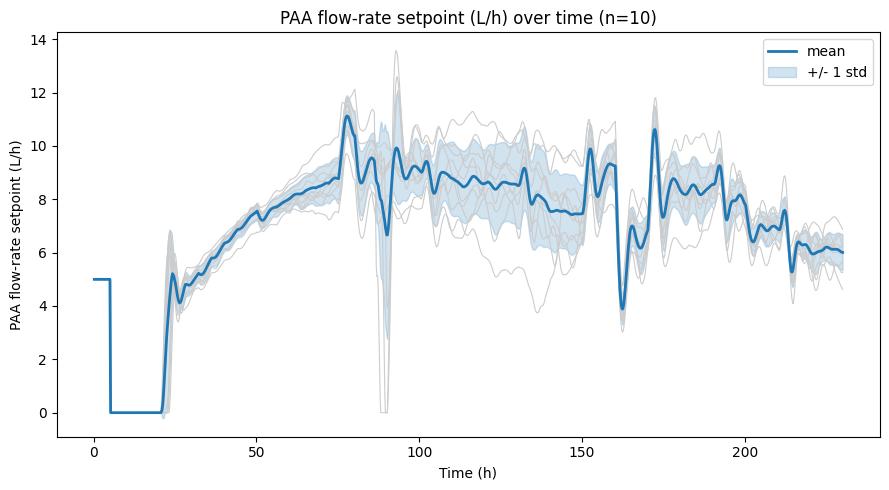

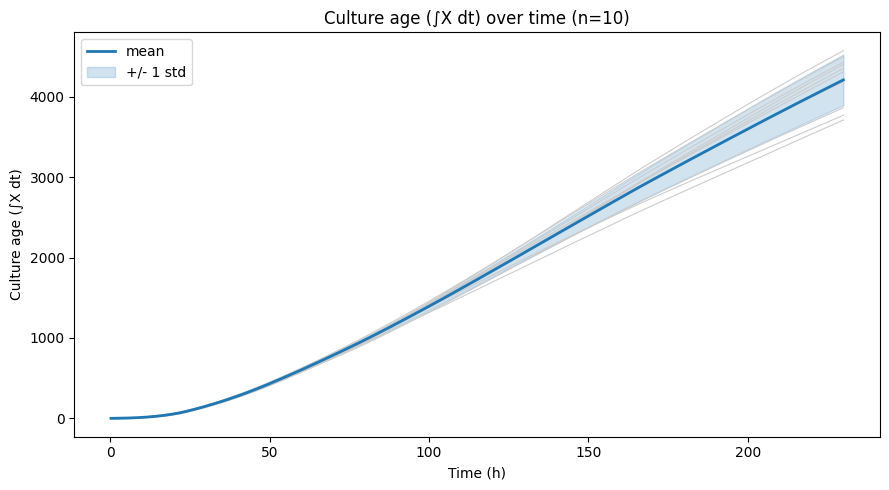

In [5]:
timeseries = {
    "Penicillin concentration (g/L)": conc_df,
    "PAA concentration (mg/L)": paa_df,
    "Viscosity (cP)": visc_df,
    "PAA flow-rate setpoint (L/h)": fpaa_df,
    "Culture age (∫X dt)": age_df,
}

for label, tdf in timeseries.items():
    mean_curve = tdf.mean(axis=1)
    std_curve = tdf.std(axis=1)
    fig, ax = plt.subplots(figsize=(9, 5))
    for c in tdf.columns:
        ax.plot(tdf.index, tdf[c], color="0.8", linewidth=0.8)
    ax.plot(mean_curve.index, mean_curve, color="C0", linewidth=2, label="mean")
    ax.fill_between(mean_curve.index, mean_curve - std_curve, mean_curve + std_curve,
                    color="C0", alpha=0.2, label="+/- 1 std")
    ax.set_xlabel("Time (h)")
    ax.set_ylabel(label)
    ax.set_title(f"{label} over time (n={N_BATCHES})")
    ax.legend()
    fig.tight_layout()
    plt.show()